# Perturbed Synthetic Datasets

Generates five datasets per protein on top of the existing naive HDF5 file:

| Dataset | Description |
|---|---|
| `ground_truth` | One-hot vectors — perfect signal |
| `perturb_gamma50` | Dirichlet, γ=50 — very mild noise |
| `perturb_gamma10` | Dirichlet, γ=10 — moderate noise |
| `perturb_gamma3` | Dirichlet, γ=3 — strong noise |
| `perturb_gamma1` | Dirichlet, γ=1 — severe noise |

For each position with true AA index `i`:
```
concentration = γ * e_i + cm_frac[i, :]
p ~ Dirichlet(concentration)
```
The CM row biases noise toward biochemically / instrumentally confused AAs.
Sampled via the Gamma-normalization trick for vectorized efficiency.

In [24]:
import sys
from pathlib import Path

import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd().parent))


def load_confusion_matrix(path: Path) -> tuple[list[str], np.ndarray]:
    data = np.load(path, allow_pickle=True).item()
    return data["classes"], data["cm_frac"].astype(np.float64)


plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
sns.set_style("whitegrid")

SRC_H5  = Path.cwd().parent / "data" / "synthetic" / "naive_n1000_seed42.h5"
OUT_H5  = Path.cwd().parent / "data" / "synthetic" / "perturbed_n1000_seed42.h5"
CM_PATH = Path.cwd().parent / "assets" / "rf_cm.npy"

SEED   = 42
GAMMAS = [50, 10, 3, 1]

classes, cm_frac = load_confusion_matrix(CM_PATH)
AA       = classes
N_AA     = len(AA)
aa_to_idx = {a: i for i, a in enumerate(AA)}
print(f"Classes: {AA}")
print(f"CM shape: {cm_frac.shape}")

Classes: ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']
CM shape: (20, 20)


In [25]:
sequences = {}
with h5py.File(SRC_H5, "r") as f:
    for pid in f:
        sequences[pid] = f[pid]["sequence"][()].decode()

print(f"Loaded {len(sequences):,} proteins")
print(f"Total residues: {sum(len(s) for s in sequences.values()):,}")

Loaded 1,000 proteins
Total residues: 551,521


In [26]:
def make_ground_truth(sequence: str) -> np.ndarray:
    """One-hot (L, 20) float32 for the true sequence."""
    true_idx = np.array([aa_to_idx[aa] for aa in sequence])
    gt = np.zeros((len(sequence), N_AA), dtype=np.float32)
    gt[np.arange(len(sequence)), true_idx] = 1.0
    return gt


def make_perturbation(sequence: str, gamma: float, rng: np.random.Generator) -> np.ndarray:
    """
    Sample p ~ Dirichlet(gamma * e_i + cm_frac[i, :]) for each position.

    Uses the Gamma-normalization identity:
        if X_j ~ Gamma(alpha_j, 1) independently, then X / sum(X) ~ Dirichlet(alpha)
    This allows fully vectorized sampling across all L positions at once.
    """
    true_idx = np.array([aa_to_idx[aa] for aa in sequence])

    concentration = cm_frac[true_idx].copy()           # (L, 20) — CM row for each true AA
    concentration[np.arange(len(sequence)), true_idx] += gamma  # add signal weight on true AA

    gamma_samples = rng.gamma(shape=concentration, scale=1.0)   # (L, 20)
    return (gamma_samples / gamma_samples.sum(axis=1, keepdims=True)).astype(np.float32)

In [27]:
rng = np.random.default_rng(SEED)

with h5py.File(OUT_H5, "w") as f:
    f.attrs["model"]   = "perturbed"
    f.attrs["classes"] = classes
    f.attrs["seed"]    = SEED
    f.attrs["gammas"]  = GAMMAS

    for pid, seq in tqdm(sequences.items(), desc="Generating"):
        grp = f.create_group(pid)
        grp.create_dataset("sequence", data=np.bytes_(seq))
        grp.create_dataset("ground_truth", data=make_ground_truth(seq), compression="gzip")
        for gamma in GAMMAS:
            grp.create_dataset(
                f"perturb_gamma{gamma}",
                data=make_perturbation(seq, gamma, rng),
                compression="gzip",
            )

print(f"Saved → {OUT_H5}")

Generating: 100%|██████████| 1000/1000 [00:06<00:00, 153.51it/s]

Saved → /Users/jonathanzhao/Desktop/Whole Sequence Model/whole_sequence_model/data/synthetic/perturbed_n1000_seed42.h5


In [33]:
SCRAMBLE_FRACS = [0.01, 0.05, 0.1, 0.2]

def make_scrambled(ground_truth, s, rng):
    L = ground_truth.shape[0]
    out = ground_truth.copy()
    n_scramble = int(round(L * s))
    if n_scramble > 0:
        positions = rng.choice(L, size=n_scramble, replace=False)
        for pos in positions:
            out[pos] = rng.permutation(out[pos])
    return out

rng_scramble = np.random.default_rng(SEED + 1)

with h5py.File(OUT_H5, 'a') as f:
    f.attrs['scramble_fracs'] = SCRAMBLE_FRACS
    for pid in tqdm(sequences, desc='Scrambling'):
        base = f[pid]['perturb_gamma50'][()]  # soft realistic base
        for s in SCRAMBLE_FRACS:
            key = f'scramble_{int(s*100)}pct'
            if key in f[pid]:
                del f[pid][key]
            f[pid].create_dataset(
                key, data=make_scrambled(base, s, rng_scramble), compression='gzip'
            )

print('Done')


Scrambling: 100%|██████████| 1000/1000 [00:06<00:00, 150.86it/s]


Done


## Verification

In [29]:
dataset_keys = ["ground_truth"] + [f"perturb_gamma{g}" for g in GAMMAS]
labels       = ["ground truth (one-hot)"] + [f"γ={g}" for g in GAMMAS]

# Load a sample for quick checks (first 100 proteins)
sample_pids = list(sequences)[:100]

entropies   = {k: [] for k in dataset_keys}
true_probs  = {k: [] for k in dataset_keys}

with h5py.File(OUT_H5, "r") as f:
    for pid in sample_pids:
        seq      = sequences[pid]
        true_idx = np.array([aa_to_idx[aa] for aa in seq])
        for key in dataset_keys:
            out = f[pid][key][()]
            p   = np.clip(out, 1e-12, None)
            entropies[key].append(-(p * np.log2(p)).sum(axis=1))
            true_probs[key].append(out[np.arange(len(seq)), true_idx])

entropies  = {k: np.concatenate(v) for k, v in entropies.items()}
true_probs = {k: np.concatenate(v) for k, v in true_probs.items()}

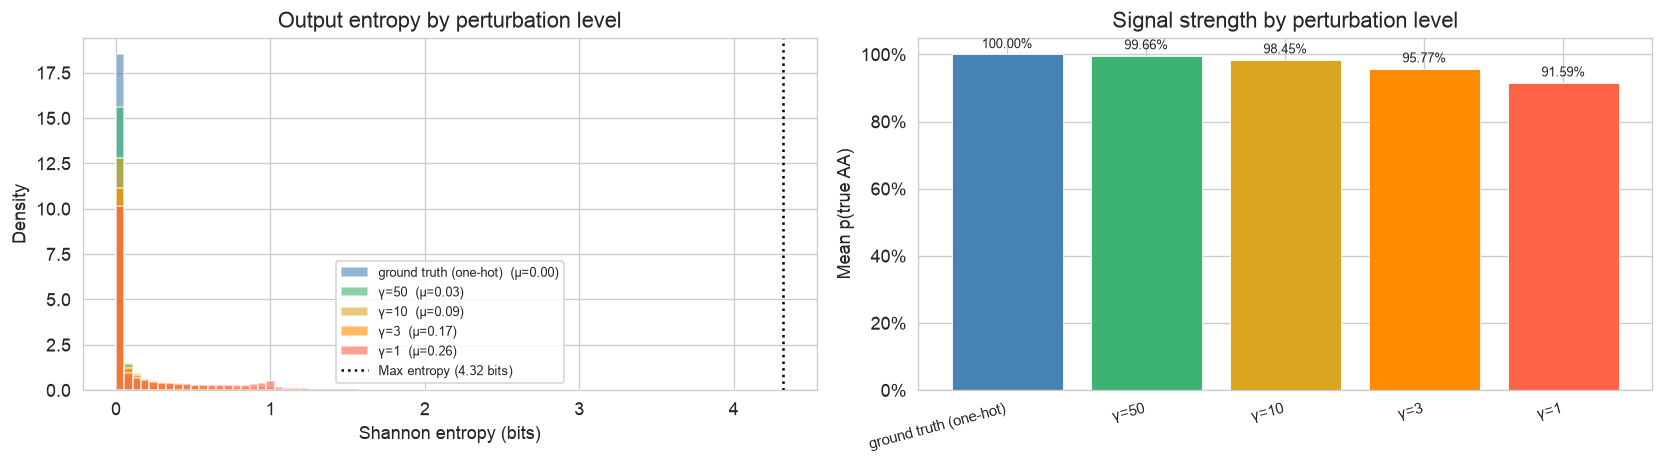

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

colors = ["steelblue", "mediumseagreen", "goldenrod", "darkorange", "tomato"]

# Entropy distributions
for key, label, color in zip(dataset_keys, labels, colors):
    axes[0].hist(
        entropies[key], bins=80, range=(0, np.log2(N_AA)), alpha=0.6,
        label=f"{label}  (μ={entropies[key].mean():.2f})",
        color=color, density=True,
    )
axes[0].axvline(np.log2(N_AA), color="black", linestyle=":", label=f"Max entropy ({np.log2(N_AA):.2f} bits)")
axes[0].set(xlabel="Shannon entropy (bits)", ylabel="Density", title="Output entropy by perturbation level")
axes[0].legend(fontsize=8)

# Mean probability assigned to true AA
mean_true = [true_probs[k].mean() for k in dataset_keys]
x = np.arange(len(dataset_keys))
bars = axes[1].bar(x, mean_true, color=colors, edgecolor="white", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
axes[1].set(ylabel="Mean p(true AA)", title="Signal strength by perturbation level", ylim=(0, 1.05))
for bar, val in zip(bars, mean_true):
    axes[1].text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.2%}",
                 ha="center", va="bottom", fontsize=8)

fig.tight_layout()
plt.show()


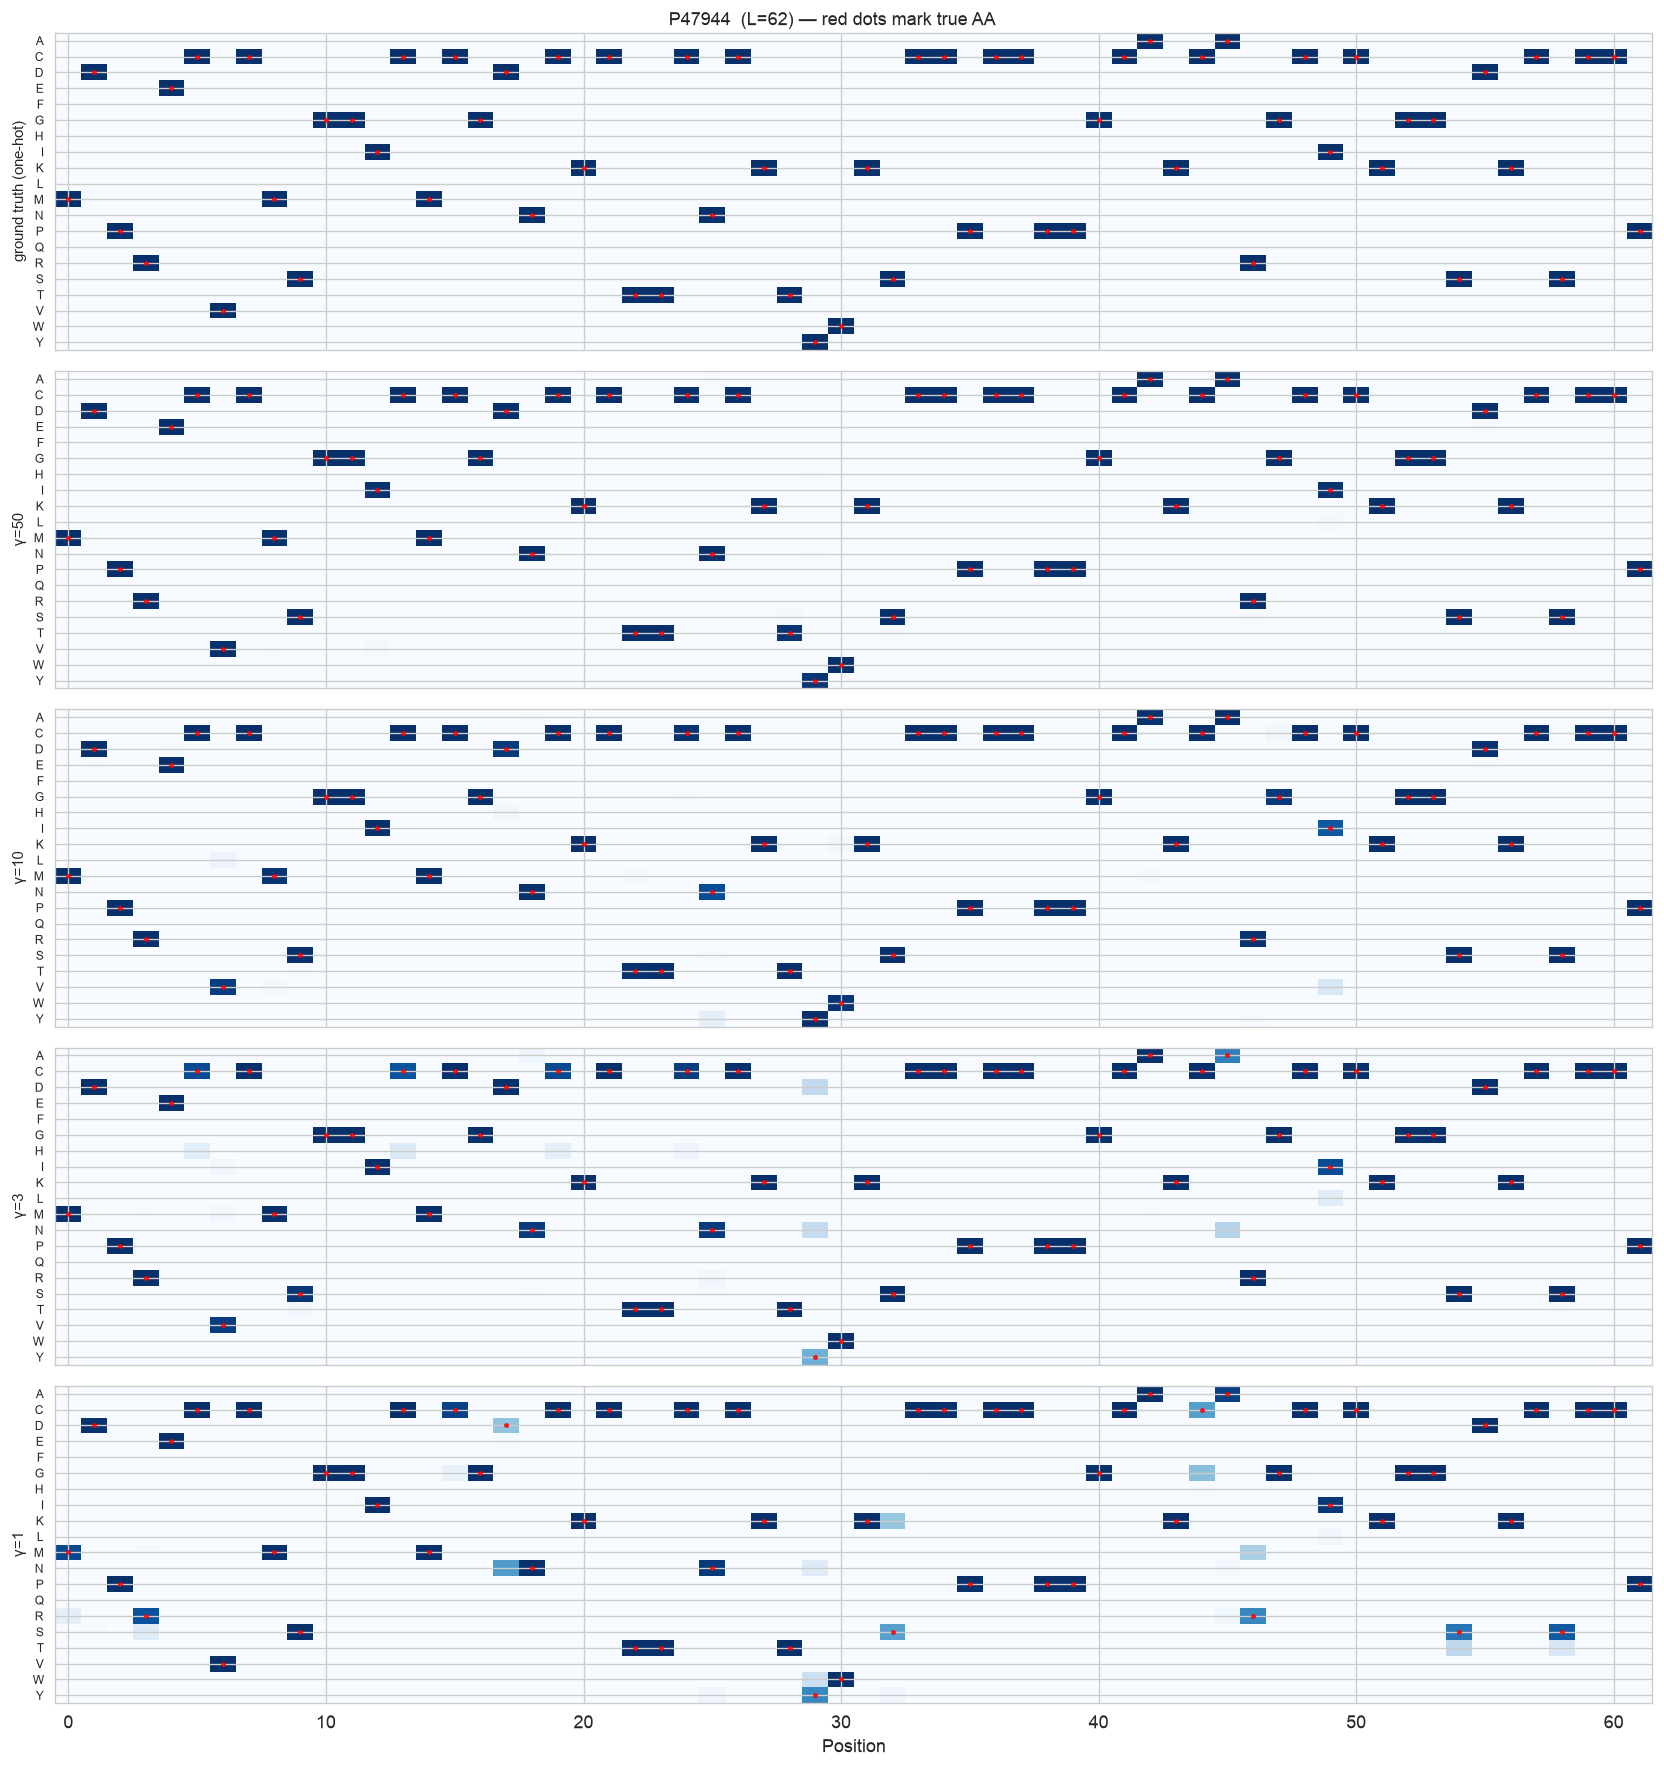

In [34]:
# Pick a short-ish protein for a readable visualization
lengths = {pid: len(seq) for pid, seq in sequences.items()}
viz_pid = min(lengths, key=lambda pid: abs(lengths[pid] - 60))
viz_seq = sequences[viz_pid]
viz_true_idx = np.array([aa_to_idx[aa] for aa in viz_seq])
L = len(viz_seq)

with h5py.File(OUT_H5, "r") as f:
    viz_outputs = {key: f[viz_pid][key][()] for key in dataset_keys}

fig, axes = plt.subplots(len(dataset_keys), 1, figsize=(max(14, L * 0.22), 3 * len(dataset_keys)), sharex=True)

for ax, key, label, color in zip(axes, dataset_keys, labels, colors):
    out = viz_outputs[key]
    im = ax.imshow(out.T, aspect="auto", cmap="Blues", vmin=0, vmax=1)
    ax.set_yticks(np.arange(N_AA))
    ax.set_yticklabels(AA, fontsize=7)
    for pos, ti in enumerate(viz_true_idx):
        ax.plot(pos, ti, "r.", markersize=4, alpha=0.8)
    ax.set_ylabel(label, fontsize=9)

axes[-1].set_xlabel("Position")
fig.suptitle(f"{viz_pid}  (L={L}) — red dots mark true AA", fontsize=11)
fig.tight_layout()
plt.show()

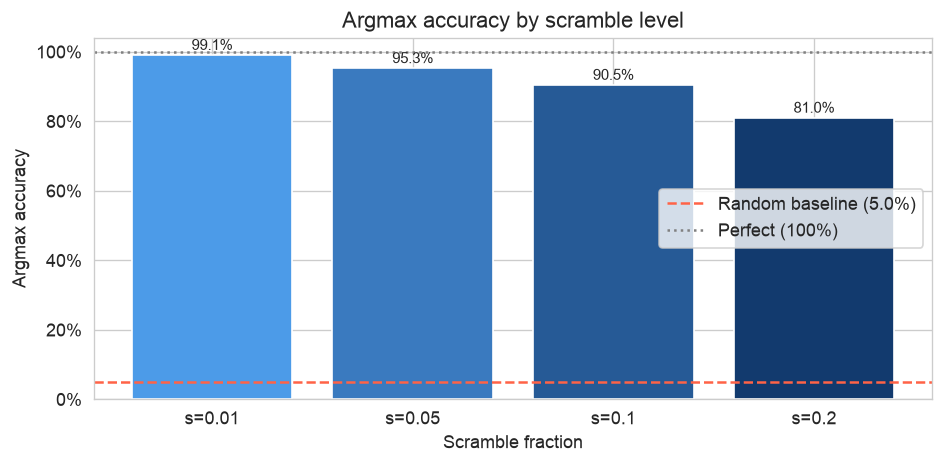

In [36]:
scramble_keys   = [f'scramble_{int(s*100)}pct' for s in SCRAMBLE_FRACS]
scramble_labels = [f's={s}' for s in SCRAMBLE_FRACS]

argmax_acc = {k: [] for k in scramble_keys} 

with h5py.File(OUT_H5, 'r') as f:
    for pid in list(sequences)[:100]:
        seq      = sequences[pid]
        true_idx = np.array([aa_to_idx[aa] for aa in seq])
        for key in scramble_keys:
            out = f[pid][key][()]
            argmax_acc[key].append((out.argmax(axis=1) == true_idx).mean())

fig, ax = plt.subplots(figsize=(8, 4))
colors_s = ['#4c9be8', '#3a7abf', '#265a96', '#123a6e']
means = [np.mean(argmax_acc[k]) for k in scramble_keys]
bars = ax.bar(np.arange(len(scramble_keys)), means, color=colors_s, edgecolor='white')
ax.axhline(1/N_AA, color='tomato', linestyle='--', label=f'Random baseline ({1/N_AA:.1%})')
ax.axhline(1.0, color='gray', linestyle=':', label='Perfect (100%)')
ax.set_xticks(np.arange(len(scramble_keys)))
ax.set_xticklabels(scramble_labels)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
ax.set(xlabel='Scramble fraction', ylabel='Argmax accuracy', title='Argmax accuracy by scramble level')
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.005, f'{val:.1%}',
            ha='center', va='bottom', fontsize=9)
ax.legend()
fig.tight_layout()
plt.show()
